In [2]:
import pandas as pd

# Load the CSV
df = pd.read_csv('data/car_data.csv')

# See the first 5 rows
df.head()


,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [3]:
# How many rows and columns?
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# What columns exist?
print(df.columns.tolist())

# Data types (numbers vs text)
print(df.dtypes)

# Any missing values?
print(df.isnull().sum())

# Basic statistics
df.describe()


Rows: 2500, Columns: 10
['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage', 'Condition', 'Price', 'Model']
Car ID            int64
Brand               str
Year              int64
Engine Size     float64
Fuel Type           str
Transmission        str
Mileage           int64
Condition           str
Price           float64
Model               str
dtype: object
Car ID          0
Brand           0
Year            0
Engine Size     0
Fuel Type       0
Transmission    0
Mileage         0
Condition       0
Price           0
Model           0
dtype: int64


,Car ID,Year,Engine Size,Mileage,Price
count,2500.00000,2500.0000,2500.000000,2500.000000,2500.000000
mean,1250.50000,2011.6268,3.465240,149749.844800,52638.022532
std,721.83216,6.9917,1.432053,87919.952034,27295.833455
min,1.00000,2000.0000,1.000000,15.000000,5011.270000
25%,625.75000,2005.0000,2.200000,71831.500000,28908.485000
50%,1250.50000,2012.0000,3.400000,149085.000000,53485.240000
75%,1875.25000,2018.0000,4.700000,225990.500000,75838.532500
max,2500.00000,2023.0000,6.000000,299967.000000,99982.590000


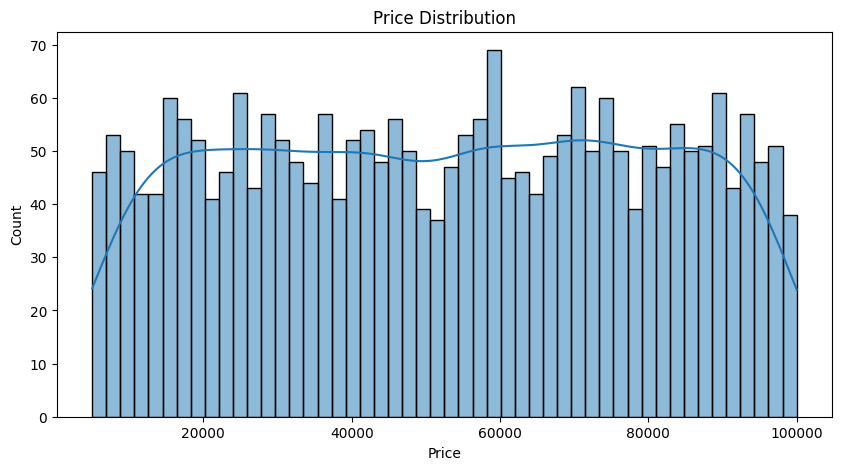

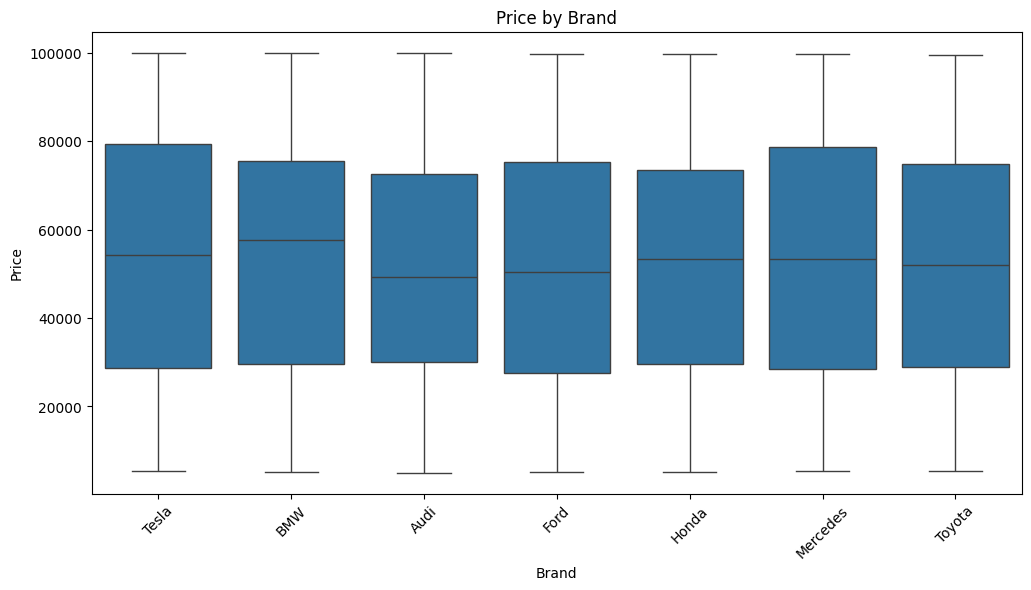

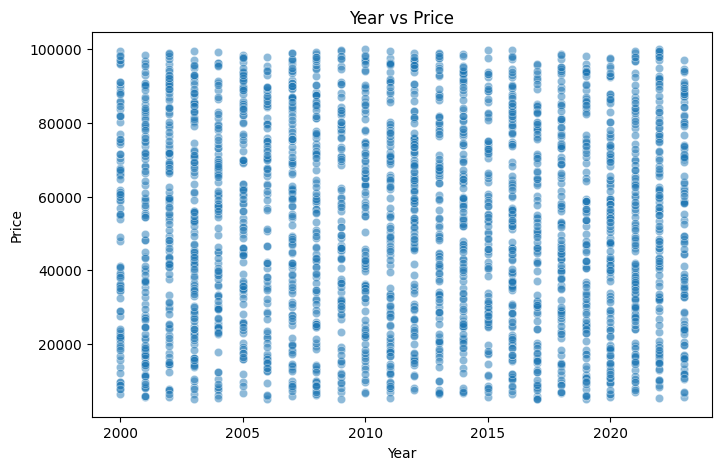

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Price distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.show()

# Price by brand (top 10)
plt.figure(figsize=(12, 6))
top_brands = df['Brand'].value_counts().head(10).index
sns.boxplot(data=df[df['Brand'].isin(top_brands)], x='Brand', y='Price')
plt.xticks(rotation=45)
plt.title('Price by Brand')
plt.show()

# Correlation between year and price
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Year', y='Price', alpha=0.5)
plt.title('Year vs Price')
plt.show()


In [5]:
# Drop rows with missing values (simplest approach)
df = df.dropna()

# Remove outliers (prices that are too extreme)
Q1 = df['Price'].quantile(0.05)
Q3 = df['Price'].quantile(0.95)
df = df[(df['Price'] >= Q1) & (df['Price'] <= Q3)]

print(f"Clean data: {df.shape[0]} rows")


Clean data: 2250 rows


In [7]:
# ⚠️ ADJUST THESE COLUMN NAMES to match YOUR dataset
# Look at what df.columns shows and pick the relevant ones

# Features = what the model will use to predict
features = ['Brand', 'Model', 'Year', 'Fuel Type', 'Transmission', 'Mileage']

# Target = what we want to predict
target = 'Price'

X = df[features]  # Input  (capital X by convention)
y = df[target]    # Output (lowercase y by convention)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (2250, 6)
Target shape: (2250,)


In [8]:
from sklearn.preprocessing import LabelEncoder

# Create an encoder for each text column
encoders = {}
X_encoded = X.copy()

for col in X.select_dtypes(include=['object']).columns:
    encoders[col] = LabelEncoder()
    X_encoded[col] = encoders[col].fit_transform(X[col])

# Now all columns are numbers!
X_encoded.head()


C:\Users\PMLS\AppData\Local\Temp\ipykernel_5812\3394454247.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X.select_dtypes(include=['object']).columns:


,Brand,Model,Year,Fuel Type,Transmission,Mileage
0,5,19,2016,3,1,114832
1,1,1,2018,1,1,143190
2,0,3,2013,1,1,181601
3,5,20,2011,0,0,68682
4,2,21,2009,0,1,223009


In [9]:
from sklearn.model_selection import train_test_split

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")


Training samples: 1800
Testing samples:  450


In [10]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
model = RandomForestRegressor(
    n_estimators=100,    # 100 decision trees (more = better but slower)
    max_depth=15,        # How deep each tree can go
    random_state=42      # For reproducible results
)

# Train it! (This is where the magic happens)
model.fit(X_train, y_train)

print("✅ Model trained!")


✅ Model trained!


📈 R² Score: -0.0605
📏 MAE:      $21056.68
📐 RMSE:     $24658.86


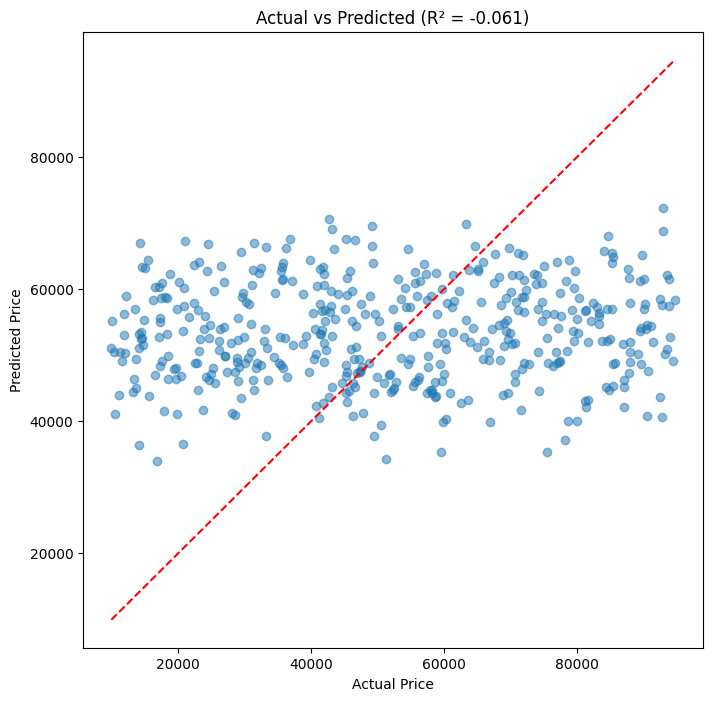

In [11]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"📈 R² Score: {r2:.4f}")    # How good (1.0 = perfect, 0 = useless)
print(f"📏 MAE:      ${mae:.2f}")   # Average error in dollars
print(f"📐 RMSE:     ${rmse:.2f}")  # Root mean squared error

# Visualize: Actual vs Predicted
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Actual vs Predicted (R² = {r2:.3f})')
plt.show()


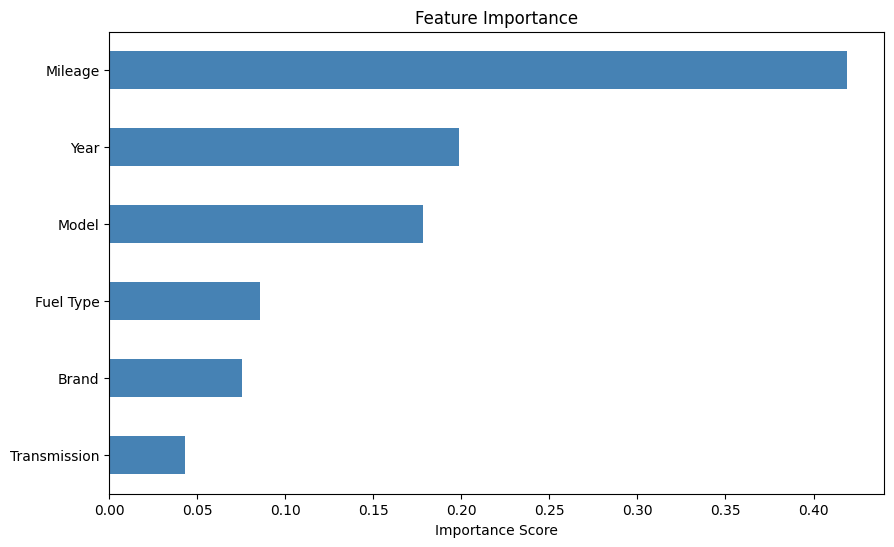

In [12]:
# Feature importance
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()


In [14]:
import joblib

# Save the model
joblib.dump(model, 'model/price_model.pkl')

# Save the encoders (we need these to convert text → numbers later)
joblib.dump(encoders, 'model/encoders.pkl')

# Save the feature list
joblib.dump(features, 'model/features.pkl')

print("✅ Model saved to model/ folder!")


✅ Model saved to model/ folder!


In [15]:
# Load the saved model
model = joblib.load('model/price_model.pkl')
encoders = joblib.load('model/encoders.pkl')

# Predict price for a new car
new_car = {
    'Brand': 'BMW',
    'Model': 'X5',
    'Year': 2022,
    'Fuel Type': 'Petrol',
    'Transmission': 'Automatic',
    'Mileage': 15000
}

# Encode the text values
import pandas as pd
new_df = pd.DataFrame([new_car])
for col, encoder in encoders.items():
    if col in new_df.columns:
        # Handle unseen values
        try:
            new_df[col] = encoder.transform(new_df[col])
        except ValueError:
            # If brand/model wasn't in training data, use -1
            new_df[col] = -1

prediction = model.predict(new_df)[0]
print(f"💰 Predicted price: ${prediction:,.2f}")


💰 Predicted price: $58,448.95
